# Horse racing data analysis

##### Data preprocessing

Pay attention to the relative path of data

In [1]:
import os
import pandas as pd
import numpy as np


file_name = 'horse_racing_data.csv'
current_path = os.getcwd()
data_path = current_path + '\\' + 'data' + '\\' + 'horse racing data' + '\\' 
df = pd.read_csv(data_path + file_name,index_col='race_id')

Drop Nan

In [2]:
#covariate_columns = ['Act. Wt.','Declar. Horse Wt.','Dr.','Win Odds']
covariate_columns = ['Act. Wt.','Dr.','Win Odds']
NaN_columns = covariate_columns+['Pla.']
for covariate in NaN_columns:
    df[covariate] = pd.to_numeric(df[covariate], errors='coerce')
    df = df.dropna(subset=[covariate])


In [3]:
df.shape

(231276, 12)

Select suitable matches and players

In [4]:
def delete_matches(df,m_lower=0,m_upper=100):
    df = df.copy()
    i = 0
    indexes = []
    for index in df.index.unique():
        m = df[df.index == index].shape[0]
        if m >= m_lower and m <= m_upper:
            i += 1
        else:
            indexes.append(index)
    df = df.drop(index = indexes)
    return df,i

def delete_players(df,d_min=0,name = 'Horse'):
    counts = df[name].value_counts()
    values_to_keep = counts[counts >= d_min].index
    df = df[df[name].isin(values_to_keep)]
    return df,len(values_to_keep)

def select(df,m_lower=0,m_upper=100,d_min=0,name = 'Horse'):
    NN = len(df.index.unique())
    nn = len(df[name].value_counts())
    while True:
        print('-'*10)
        print(f'The number of matches: {NN}')
        print(f'The number of horses: {nn}')
        df,N = delete_matches(df,m_lower,m_upper)
        df,n = delete_players(df,d_min)
        if NN == N and nn == n:
            break
        else:
            NN = N
            nn = n
    return df,n,N

In [5]:
m_lower = 4
m_upper = 14
d_min = 25
df,n,N = select(df,m_lower,m_upper,d_min)

----------
The number of matches: 18644
The number of horses: 11256
----------
The number of matches: 18644
The number of horses: 3969
----------
The number of matches: 17915
The number of horses: 3872
----------
The number of matches: 17681
The number of horses: 3828
----------
The number of matches: 17521
The number of horses: 3800
----------
The number of matches: 17418
The number of horses: 3768
----------
The number of matches: 17277
The number of horses: 3740
----------
The number of matches: 17178
The number of horses: 3725
----------
The number of matches: 17124
The number of horses: 3717
----------
The number of matches: 17090
The number of horses: 3709
----------
The number of matches: 17059
The number of horses: 3701
----------
The number of matches: 17027
The number of horses: 3693
----------
The number of matches: 16998
The number of horses: 3689
----------
The number of matches: 16984
The number of horses: 3687
----------
The number of matches: 16974
The number of horses:

Normalization

In [6]:
# Actual Weight
df['Act. Wt.'] = np.log(df['Act. Wt.'])
mean_A = df['Act. Wt.'].mean()
std_A = df['Act. Wt.'].std()
df['Act. Wt.'] = (df['Act. Wt.'] - mean_A) / std_A
# Draw
df['Dr.']
for index in df.index.unique():
    df.loc[index,'Dr.'] = pd.Series(df.loc[index,'Dr.']/max(df.loc[index,'Dr.'])).astype(float)
# Belief
for index in df.index.unique():
    t = df.loc[index,'Win Odds']
    df.loc[index,'Win Odds'] = np.log((1 / t) / np.sum(1 / t))

In [7]:
df.to_csv(data_path+'horse_racing_data(preprocessing).csv')

##### Data Analysis

In [8]:
import os
import pandas as pd
import numpy as np

current_path = os.getcwd()
data_path = current_path + '\\' + 'data' + '\\' 
processed_data = 'horse_racing_data(preprocessing).csv'
df = pd.read_csv(data_path + processed_data,index_col='race_id')

C:\Users\13299\AppData\Local\Temp\ipykernel_9492\176213610.py:8: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path + processed_data,index_col='race_id')


Construct T and X

In [9]:
name_columns = 'Horse'
covariate_columns = ['Act. Wt.','Dr.','Win Odds']

horseID = {}
T = []
X = []
for index in df.index.unique():
    x = np.array(df[covariate_columns].loc[index])
    X.append(x)

    t = []
    horses_name = df[name_columns].loc[index].tolist()
    for horse_name in horses_name:
        added_horse = horseID.keys()
        if horse_name in added_horse:
            pass
        else:
            n = len(added_horse)
            horseID[horse_name] = n
        t.append(horseID[horse_name])
    T.append(t)

###### PlusDC

In [10]:
from package import algorithm
d = 3
u_plusDC,v_plusDC = algorithm.AM(T,X,n,d,detail=True)

-----1-----
log-likelihood: -12.235750155257655
u iterative times: 316
v iterative times: 4 and v = [-0.03670322 -0.10804422  0.58424038]
-----2-----
log-likelihood: -11.316849455902082
u iterative times: 215
v iterative times: 4 and v = [-0.14066861 -0.22365515  0.43333756]
-----3-----
log-likelihood: -11.179162285780725
u iterative times: 188
v iterative times: 4 and v = [-0.10309349 -0.14680965  0.55866978]
-----4-----
log-likelihood: -11.143339605656427
u iterative times: 148
v iterative times: 3 and v = [-0.14022612 -0.17853835  0.51697554]
-----5-----
log-likelihood: -11.133537824654232
u iterative times: 104
v iterative times: 3 and v = [-0.12167213 -0.15601878  0.54732101]
-----6-----
log-likelihood: -11.130611552796669
u iterative times: 70
v iterative times: 3 and v = [-0.13377147 -0.16472866  0.53591434]
-----7-----
log-likelihood: -11.129766254556484
u iterative times: 30
v iterative times: 3 and v = [-0.12721683 -0.1591468   0.54322342]
-----8-----
log-likelihood: -11.1295

In [11]:
plusDC_top10 = np.argsort(u_plusDC)[-10:][::-1]
u_t10_plusDC = u_plusDC[plusDC_top10]
i = 0
for index, uu in zip(plusDC_top10,u_t10_plusDC):
    i += 1
    horse_name = [key for key, value in horseID.items() if value == index][0]
    print(f'top-{i}: horse name:{horse_name}, score:{uu}')

top-1: horse name:GOLDEN SIXTY (C238), score:2.8938899195260523
top-2: horse name:EXULTANT (B101), score:2.8191234238361513
top-3: horse name:TOURBILLON DIAMOND (E054), score:2.467705910644825
top-4: horse name:BEAUTY GENERATION (V380), score:2.323162358326596
top-5: horse name:SEASONS BLOOM (V410), score:2.2548677350325557
top-6: horse name:GOLD-FUN (P045), score:2.1656705916596906
top-7: horse name:MILITARY ATTACK (N175), score:2.069620962827158
top-8: horse name:DUKE WAI (C188), score:2.0117963139763795
top-9: horse name:COLUMBUS COUNTY (C465), score:2.009501591862466
top-10: horse name:BUTTERFIELD (C462), score:2.0083663577861435


In [12]:
l_plusDC = algorithm.multi_likelihood(T,X,n,u_plusDC,v_plusDC)
l_plusDC

-11.129434631682653

###### PL

In [13]:
u_pl,v_pl = algorithm.AM(T,X,P=True,detail=True)

In [14]:
l_pl = algorithm.multi_likelihood(T,X,u_pl,v_pl)
l_pl

-11.682455129967053

In [15]:
i=0
for index, uu in zip(plusDC_top10,u_t10_plusDC):
    i += 1
    horse_name = [key for key, value in horseID.items() if value == index][0]
    print(f'top-{i}: horse name:{horse_name}, score(PlusDC):{uu},score(PL):{u_pl[index]}')

top-1: horse name:GOLDEN SIXTY (C238), score(PlusDC):2.8938899195260523,score(PL):5.512124690955247
top-2: horse name:EXULTANT (B101), score(PlusDC):2.8191234238361513,score(PL):4.634828153848856
top-3: horse name:TOURBILLON DIAMOND (E054), score(PlusDC):2.467705910644825,score(PL):3.91817035090454
top-4: horse name:BEAUTY GENERATION (V380), score(PlusDC):2.323162358326596,score(PL):4.244364869178965
top-5: horse name:SEASONS BLOOM (V410), score(PlusDC):2.2548677350325557,score(PL):3.5849271250130332
top-6: horse name:GOLD-FUN (P045), score(PlusDC):2.1656705916596906,score(PL):3.6325954592419105
top-7: horse name:MILITARY ATTACK (N175), score(PlusDC):2.069620962827158,score(PL):2.8919008958163177
top-8: horse name:DUKE WAI (C188), score(PlusDC):2.0117963139763795,score(PL):3.5377289847780142
top-9: horse name:COLUMBUS COUNTY (C465), score(PlusDC):2.009501591862466,score(PL):3.264071733356026
top-10: horse name:BUTTERFIELD (C462), score(PlusDC):2.0083663577861435,score(PL):3.05692087494

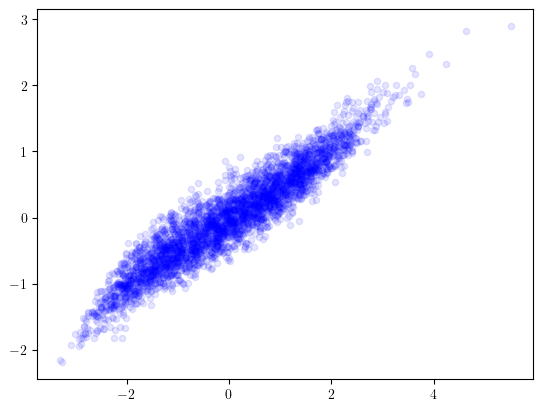

In [16]:
import matplotlib.pyplot as plt

plt.scatter(u_pl,u_plusDC,s = 20,alpha=0.1,c='blue')